# Multi-harmonic fit

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import dill
from scipy.optimize import curve_fit

## Posterior samples

In [2]:
### get the posterior data
file_name = 'jnkep_fit_k2-19_nburn-1000_nsteps-1000_emax=0.5.pkl'

working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")

file_path = os.path.join(data_dir, file_name)

In [3]:
with open(file_name, "rb") as f:
    mcmc = dill.load(f)
mcmc.print_summary()
print(mcmc)


                      mean       std    median      5.0%     95.0%     n_eff     r_hat
 ecosw_scaled[0]      0.44      0.06      0.45      0.35      0.52   1089.88      1.00
 ecosw_scaled[1]      0.47      0.04      0.47      0.40      0.53   1087.59      1.00
 esinw_scaled[0]      0.46      0.08      0.47      0.34      0.58    565.62      1.00
 esinw_scaled[1]      0.42      0.06      0.43      0.31      0.51    555.89      1.00
period_scaled[0]      0.50      0.00      0.50      0.50      0.50    641.41      1.00
period_scaled[1]      0.51      0.01      0.51      0.50      0.52    763.49      1.00
 pmass_scaled[0]      0.11      0.01      0.10      0.10      0.11    510.85      1.01
 pmass_scaled[1]      0.04      0.00      0.04      0.04      0.04   1047.51      1.01
   tic_scaled[0]      0.50      0.00      0.50      0.49      0.50   1985.31      1.00
   tic_scaled[1]      0.52      0.01      0.52      0.49      0.53   1548.75      1.00

Number of divergences: 198


In [4]:
# Posterior samples
posterior_samples = mcmc.get_samples()

# Shape of samples
print({k: v.shape for k, v in posterior_samples.items()})

samples = mcmc.get_samples()

{'ecc': (8000, 2), 'ecosw': (8000, 2), 'ecosw_scaled': (8000, 2), 'ediff': (8000,), 'esinw': (8000, 2), 'esinw_scaled': (8000, 2), 'period': (8000, 2), 'period_scaled': (8000, 2), 'pmass': (8000, 2), 'pmass_scaled': (8000, 2), 'tcmodel': (8000, 33), 'tic': (8000, 2), 'tic_scaled': (8000, 2)}


In [5]:
### conversions
solar_mass_2_kg = 1.989e30 # [kg per solar mass]
d_2_s = 86400 # [seconds per day]

### system constants 
m_star = 0.88  # [solar mass]

from astropy import units as u
from astropy import constants as c
G_const_si = c.G
G_const = c.G.to(u.AU**3 / u.M_sun / u.day**2).value


### posterior samples 
ecosw_b = samples["ecosw"][:, 0]
esinw_b = samples["esinw"][:, 0]
e_b = samples["ecc"][:,0]
P_b = samples["period"][:,0] # [days]
Tc_b = samples["tic"][:,0] # [days]
m_b = samples["pmass"][:,0] # [solar mass]

ecosw_c = samples["ecosw"][:, 1]
esinw_c = samples["esinw"][:, 1]
e_c = samples["ecc"][:,1]
P_c = samples["period"][:,1] # [days]
Tc_c = samples["tic"][:,1] # [days]
m_c = samples["pmass"][:,1] # [solar mass]  


## Transit time data

In [6]:
### get data from jnkepler fit
import json

# Load the data from the JSON file
with open("jnkep_fit_data.json", "r") as f:
    data = json.load(f)
# Access values just like a dictionary
# t_jnkep_b = data["jnkep_model_times"]["b"]
# t_jnkep_c = data["jnkep_model_times"]["c"]

t_obs_b = data["jnkep_observed_times"]["b"]
t_obs_c = data["jnkep_observed_times"]["c"]

t_obs_err_b = data["jnkep_observed_times_err"]["b"]
t_obs_err_c = data["jnkep_observed_times_err"]["c"]

index_obs_b = data["jnkep_observed_index"]["b"]
index_obs_c = data["jnkep_observed_index"]["c"]

# Ensure these are numpy arrays
index_obs_b = np.array(index_obs_b)
index_obs_c = np.array(index_obs_c)

t_obs_b = np.array(t_obs_b)
t_obs_c = np.array(t_obs_c)
t_obs_err_b = np.array(t_obs_err_b)
t_obs_err_c = np.array(t_obs_err_c)

## Multi-harmonic fit 

In [7]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [8]:
j = 3 # 3:2 MMR
p_b = np.median(P_b)
p_c = np.median(P_c)
tc_b = np.median(Tc_b)
tc_c = np.median(Tc_c)


delta = delta_(p_b, p_c, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_c, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.0023067792256672437
TTV period: 1720.496106938662 days


In [9]:
# t_b = t_b_0 + P_b*i_b + A_bc*np.sin((2*np.pi)/(P_bc*(t-t_bc_0)))
# def model_b(t, t_b_0, P_b, i_b, A_bc, P_bc, t_bc_0):
#     t_b = t_b_0 + P_b*i_b + A_bc*np.sin((2*np.pi)/(P_bc*(t-t_bc_0)))  
#     return t_b


# # t_c = t_c_0 + P_c*i_c + A_cb*np.sin((2*np.pi)/(P_cb*(t-t_cb_0)))
# def model_c(t, t_c_0, P_c, i_c, A_cb, P_cb, t_cb_0):
#     t_c = t_c_0 + P_c*i_c + A_cb*np.sin((2*np.pi)/(P_cb*(t-t_cb_0)))
#     return t_c
### we set P_bc = P_cb and t_bc_0 = t_cb_0

In [10]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])



In [11]:
### let 8 params vary: t_b_0, P_b, A_bc, P_bc, t_bc, t_c_0, P_c, A_cb

In [12]:
# Initial guesses for parameters
initial_t_b0 = tc_b
initial_P_b = p_b
initial_A_bc = .012    ####
initial_t_c0 = tc_c
initial_P_c = p_c
initial_A_cb =  0.2   ####
initial_P_cb = 1000 #ttv_period
initial_t_cb0 = tc_b   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [13]:
from scipy.optimize import least_squares


### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(index_obs_b, t_obs_b, t_obs_err_b, index_obs_c, t_obs_c, t_obs_err_c),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 2.02792346e+03  7.92085954e+00 -3.02294454e-02  2.01991540e+03
  1.18991997e+01  1.15280601e-01  7.82183711e+02  1.91793665e+03]


In [14]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))

In [15]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 2027.92346284 ± 0.00065708
   P_b = 7.92085954 ± 0.00002078
  A_bc = -0.03022945 ± 0.00087486
  t_c0 = 2019.91540317 ± 0.00336289
   P_c = 11.89919967 ± 0.00011051
  A_cb = 0.11528060 ± 0.00391731
  P_cb = 782.18371070 ± 9.08159602
 t_cb0 = 1917.93665103 ± 2.05565571


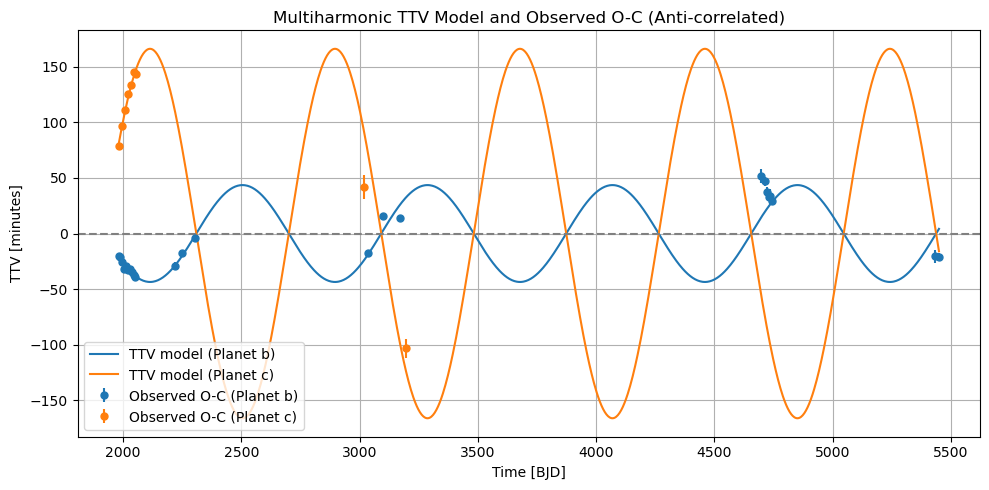

In [16]:
# Combine observed times to set the time range
all_times = np.concatenate([t_obs_b, t_obs_c])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) * 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) * 1440  # <- NEGATE here

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(index_obs_b)
t_lin_obs_c = t_c0 + P_c * np.array(index_obs_c)

# Observed O-C residuals in minutes
oc_b = (np.array(t_obs_b) - t_lin_obs_b) * 1440
oc_c = (np.array(t_obs_c) - t_lin_obs_c) * 1440

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(t_dense, ttv_b, label="TTV model (Planet b)", color='tab:blue')
plt.plot(t_dense, ttv_c, label="TTV model (Planet c)", color='tab:orange')

plt.errorbar(t_lin_obs_b, oc_b, yerr=np.array(t_obs_err_b)*1440, fmt='o',
             color='tab:blue', label='Observed O-C (Planet b)', markersize=5)
plt.errorbar(t_lin_obs_c, oc_c, yerr=np.array(t_obs_err_c)*1440, fmt='o',
             color='tab:orange', label='Observed O-C (Planet c)', markersize=5)

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Time [BJD]")
plt.ylabel("TTV [minutes]")
plt.title("Multiharmonic TTV Model and Observed O-C (Anti-correlated)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_88084/4105001438.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


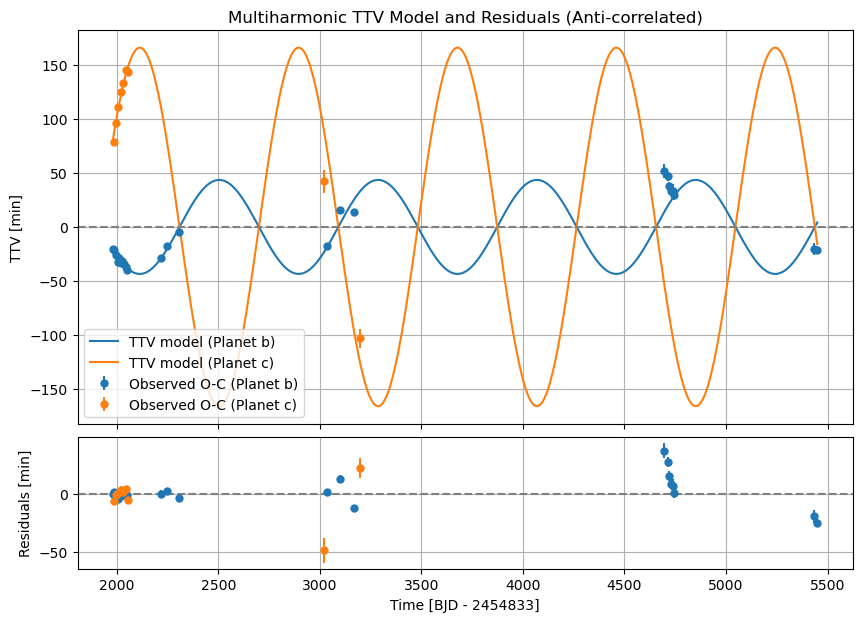

In [17]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) * 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) * 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet b)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet c)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(t_obs_err_b)*1440, fmt='o',
             color='tab:blue', label='Observed O-C (Planet b)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(t_obs_err_c)*1440, fmt='o',
             color='tab:orange', label='Observed O-C (Planet c)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [min]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(t_obs_err_b)*1440, fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(t_obs_err_c)*1440, fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [min]")
ax2.grid(True)

plt.tight_layout()
plt.show()


## Using other method

In [ ]:
k=3
f1 = -2.025
f2 = 2.484

def nes_ttv_per(P1, P2, P_tau, m1, m2, m_star, k, f1, f2):
    term1 = (P1+P2)/2
    term2 = P_tau / (2*np.pi)
    term3 = ((m1+m2)/m_star)**(-2./3.)
    term4 = ((3./2.)*k*(k-1)*np.abs(f1)*f2)**(-1./3.)
    per = term1 * term2 * term3 * term4
    return per

def A1(P_tau,